# Brain-Inspired Adversarial Robustness — Phases 2–4
**Phase 2:** Define three brain-inspired architectures  
**Phase 3:** Train each & evaluate with FGSM / PGD  
**Phase 4:** Comparative analysis with baseline

## Common Setup (Environment, Data, Utilities)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pickle, copy, time, os
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent

# ── Device ────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_label = "NVIDIA CUDA GPU"
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    device_label = "Apple Metal (MPS) GPU"
else:
    device = torch.device("cpu")
    device_label = "CPU (no GPU found)"

art_device = "cpu" if device.type == "mps" else str(device)

# ── Reproducibility ───────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if device.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
elif device.type == "mps":
    torch.mps.manual_seed(SEED)

print("=" * 40)
print("       Environment Ready!")
print("=" * 40)
print(f"  PyTorch version : {torch.__version__}")
print(f"  Training device : {device_label}")
print(f"  ART device      : {art_device}")
print(f"  Random seed     : {SEED}")
print("=" * 40)

       Environment Ready!
  PyTorch version : 2.9.1
  Training device : Apple Metal (MPS) GPU
  ART device      : cpu
  Random seed     : 42


In [2]:
# ── Load CIFAR-10 ─────────────────────────────────────────────────────
CIFAR10_PATH = "./cifar-10-batches-py"

def unpickle(file):
    with open(file, "rb") as f:
        return pickle.load(f, encoding="bytes")

meta = unpickle(f"{CIFAR10_PATH}/batches.meta")
CIFAR10_CLASSES = [c.decode("utf-8") for c in meta[b"label_names"]]

train_images, train_labels = [], []
for i in range(1, 6):
    batch = unpickle(f"{CIFAR10_PATH}/data_batch_{i}")
    train_images.append(batch[b"data"])
    train_labels.extend(batch[b"labels"])
train_images = np.vstack(train_images)
train_labels = np.array(train_labels)

test_batch  = unpickle(f"{CIFAR10_PATH}/test_batch")
test_images = test_batch[b"data"]
test_labels = np.array(test_batch[b"labels"])

train_images = train_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
test_images  = test_images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

print(f"Train: {train_images.shape}  Test: {test_images.shape}")

Train: (50000, 32, 32, 3)  Test: (10000, 32, 32, 3)


In [3]:
# ── Dataset & DataLoaders ─────────────────────────────────────────────
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)
BATCH_SIZE   = 128

class CIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        from PIL import Image
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, int(self.labels[idx])

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

train_dataset = CIFAR10Dataset(train_images, train_labels, transform=train_transform)
test_dataset  = CIFAR10Dataset(test_images,  test_labels,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(device.type == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(device.type == "cuda"))

print(f"Train batches: {len(train_loader)}  Test batches: {len(test_loader)}")

Train batches: 391  Test batches: 79


In [4]:
# ── Training & Evaluation Utilities ───────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, 100.0 * correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / total, 100.0 * correct / total

def clean_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = model(images).max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return 100.0 * correct / total

def denormalize(tensor):
    mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0.0, 1.0)

def adversarial_accuracy(art_clf, loader, attack, n_batches=None):
    correct, total = 0, 0
    for i, (images, labels) in enumerate(loader):
        if n_batches and i >= n_batches:
            break
        images_np = denormalize(images).numpy()
        labels_np = labels.numpy()
        images_adv = attack.generate(x=images_np)
        preds = np.argmax(art_clf.predict(images_adv), axis=1)
        correct += (preds == labels_np).sum()
        total   += labels_np.shape[0]
    return 100.0 * correct / total

print("Utilities ready.")

Utilities ready.


In [5]:
# ── Full Training Loop (reusable for any model) ──────────────────────

def train_model(model, model_name, save_path, num_epochs=100):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9,
                          weight_decay=5e-4, nesterov=True)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                          T_max=num_epochs, eta_min=1e-4)

    best_acc, best_weights = 0.0, None
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    print("=" * 65)
    print(f"  Training {model_name} for {num_epochs} epochs")
    print(f"  Device: {device}")
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Parameters: {total_params:,}")
    print("=" * 65)
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
          f"{'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8}")
    print("-" * 65)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc     = evaluate(model, test_loader, criterion, device)
        scheduler.step()
        lr = scheduler.get_last_lr()[0]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        tag = ""
        if val_acc > best_acc:
            best_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())
            tag = "best"

        elapsed = time.time() - t0
        print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
              f"{val_loss:>8.4f} | {val_acc:>8.2f}% | {lr:>8.6f}  "
              f"{tag}  ({elapsed:.1f}s)")

    torch.save(best_weights, save_path)
    model.load_state_dict(best_weights)
    print("=" * 65)
    print(f"  {model_name} — Best val accuracy: {best_acc:.2f}%")
    print(f"  Weights saved to: {save_path}")
    print("=" * 65)
    return model, history, best_acc

print("Training function ready.")

Training function ready.


---
## Phase 2 — Brain-Inspired Architecture Definitions

In [6]:
# ── Baseline model class (needed for reference / loading weights) ────

class ResNet18_CIFAR10(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.model(x)

print("Baseline class defined.")

Baseline class defined.


In [7]:
# ══════════════════════════════════════════════════════════════════════
# Model 1 — RecurrentResNet18 (Recurrent Processing)
# Bio motivation: Top-down / lateral recurrent connections allow
#   iterative feature refinement. Humans need processing time to
#   resist adversarial examples.
# Implementation: Shared-weight recurrent refinement block (two 3×3
#   convs + BN) applied T times after layer4, with residual skips.
# ══════════════════════════════════════════════════════════════════════

class RecurrentBlock(nn.Module):
    """Shared-weight recurrent refinement block."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(channels)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + residual)
        return out


class RecurrentResNet18(nn.Module):
    """ResNet-18 + shared-weight recurrent block after layer4."""
    def __init__(self, num_classes=10, time_steps=3):
        super().__init__()
        self.time_steps = time_steps

        base = models.resnet18(weights=None)
        base.conv1   = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()

        self.conv1  = base.conv1
        self.bn1    = base.bn1
        self.relu   = base.relu
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc     = nn.Linear(512, num_classes)

        # Shared-weight recurrent block (same weights reused T times)
        self.recurrent_block = RecurrentBlock(channels=512)

    def forward(self, x, time_steps=None):
        T = time_steps if time_steps is not None else self.time_steps
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        for _ in range(T):
            x = self.recurrent_block(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("Model 1 — RecurrentResNet18 defined.")

Model 1 — RecurrentResNet18 defined.


In [8]:
# ══════════════════════════════════════════════════════════════════════
# Model 2 — NoisyResNet18 (Noise Injection)
# Bio motivation: Neural stochasticity provides natural robustness
#   to small perturbations.
# Implementation: GaussianNoise(sigma=0.1) layers injected after
#   each residual stage, active during BOTH training and inference.
# ══════════════════════════════════════════════════════════════════════

class GaussianNoise(nn.Module):
    """Additive Gaussian noise — always on (train + inference)."""
    def __init__(self, sigma=0.1):
        super().__init__()
        self.sigma = sigma

    def forward(self, x):
        noise = torch.randn_like(x) * self.sigma
        return x + noise


class NoisyResNet18(nn.Module):
    """ResNet-18 + Gaussian noise after each residual stage."""
    def __init__(self, num_classes=10, sigma=0.1):
        super().__init__()
        base = models.resnet18(weights=None)
        base.conv1   = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()

        self.conv1  = base.conv1
        self.bn1    = base.bn1
        self.relu   = base.relu
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc     = nn.Linear(512, num_classes)

        # Noise after each stage
        self.noise1 = GaussianNoise(sigma)
        self.noise2 = GaussianNoise(sigma)
        self.noise3 = GaussianNoise(sigma)
        self.noise4 = GaussianNoise(sigma)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.noise1(self.layer1(x))
        x = self.noise2(self.layer2(x))
        x = self.noise3(self.layer3(x))
        x = self.noise4(self.layer4(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("Model 2 — NoisyResNet18 defined.")

Model 2 — NoisyResNet18 defined.


In [9]:
# ══════════════════════════════════════════════════════════════════════
# Model 3 — AttentionResNet18 (Selective Attention)
# Bio motivation: Selective attention filters salient features and
#   suppresses adversarial noise.
# Implementation: Squeeze-and-Excitation (SE) blocks after each
#   residual stage (reduction=16).
# ══════════════════════════════════════════════════════════════════════

class SEBlock(nn.Module):
    """Squeeze-and-Excitation block."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        mid = channels // reduction
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.squeeze(x).view(b, c)
        w = self.excitation(w).view(b, c, 1, 1)
        return x * w


class AttentionResNet18(nn.Module):
    """ResNet-18 + SE blocks after each residual stage."""
    def __init__(self, num_classes=10, reduction=16):
        super().__init__()
        base = models.resnet18(weights=None)
        base.conv1   = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        base.maxpool = nn.Identity()

        self.conv1  = base.conv1
        self.bn1    = base.bn1
        self.relu   = base.relu
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc     = nn.Linear(512, num_classes)

        # SE after each stage (64, 128, 256, 512 channels)
        self.se1 = SEBlock(64,  reduction)
        self.se2 = SEBlock(128, reduction)
        self.se3 = SEBlock(256, reduction)
        self.se4 = SEBlock(512, reduction)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.se1(self.layer1(x))
        x = self.se2(self.layer2(x))
        x = self.se3(self.layer3(x))
        x = self.se4(self.layer4(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("Model 3 — AttentionResNet18 defined.")

Model 3 — AttentionResNet18 defined.


In [10]:
# ── Verify all architectures ──────────────────────────────────────────
dummy = torch.randn(1, 3, 32, 32).to(device)
baseline_params = 11_173_962

for name, mdl in [("RecurrentResNet18", RecurrentResNet18()),
                   ("NoisyResNet18",     NoisyResNet18()),
                   ("AttentionResNet18", AttentionResNet18())]:
    mdl = mdl.to(device)
    with torch.no_grad():
        out = mdl(dummy)
    p = sum(x.numel() for x in mdl.parameters())
    overhead = p - baseline_params
    print(f"{name:>22s} | output: {list(out.shape)} | "
          f"params: {p:,} | overhead: +{overhead:,} ({100*overhead/baseline_params:.2f}%)")

# Recurrent model — test variable time steps
r = RecurrentResNet18().to(device)
for t in [1, 2, 3, 4]:
    with torch.no_grad():
        o = r(dummy, time_steps=t)
    print(f"  RecurrentResNet18 T={t} → {list(o.shape)}")

print("\nAll architectures verified.")

     RecurrentResNet18 | output: [1, 10] | params: 15,894,602 | overhead: +4,720,640 (42.25%)
         NoisyResNet18 | output: [1, 10] | params: 11,173,962 | overhead: +0 (0.00%)
     AttentionResNet18 | output: [1, 10] | params: 11,217,482 | overhead: +43,520 (0.39%)
  RecurrentResNet18 T=1 → [1, 10]
  RecurrentResNet18 T=2 → [1, 10]
  RecurrentResNet18 T=3 → [1, 10]
  RecurrentResNet18 T=4 → [1, 10]

All architectures verified.


---
## Phase 3 — Training & Attack Evaluation

In [11]:
# ── Train Model 1: RecurrentResNet18 ─────────────────────────────────
recurrent_model = RecurrentResNet18(num_classes=10, time_steps=3)
recurrent_model, recurrent_hist, recurrent_best = train_model(
    recurrent_model, "RecurrentResNet18", "recurrent_resnet18.pth", num_epochs=100
)

  Training RecurrentResNet18 for 100 epochs
  Device: mps
  Parameters: 15,894,602
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
-----------------------------------------------------------------
     1 |     2.5744 |    20.35% |   1.9417 |    23.92% | 0.099975  best  (112.2s)
     2 |     1.8568 |    29.22% |   1.8048 |    31.23% | 0.099901  best  (113.6s)
     3 |     1.6931 |    36.13% |   1.6617 |    36.53% | 0.099778  best  (114.4s)
     4 |     1.5169 |    43.58% |   1.4907 |    43.99% | 0.099606  best  (114.5s)
     5 |     1.3382 |    51.37% |   1.4121 |    46.96% | 0.099385  best  (114.5s)
     6 |     1.1263 |    59.57% |   1.1392 |    59.57% | 0.099115  best  (114.6s)
     7 |     0.9375 |    67.05% |   1.1804 |    63.12% | 0.098797  best  (114.4s)
     8 |     0.7918 |    72.39% |   1.2459 |    61.09% | 0.098431    (114.1s)
     9 |     0.6975 |    75.80% |   0.7738 |    73.30% | 0.098017  best  (114.2s)
    10 |     0.6355 |    77.94% |   0.6512 |    78.1

In [12]:
# ── Train Model 2: NoisyResNet18 ─────────────────────────────────────
noisy_model = NoisyResNet18(num_classes=10, sigma=0.1)
noisy_model, noisy_hist, noisy_best = train_model(
    noisy_model, "NoisyResNet18", "noisy_resnet18.pth", num_epochs=100
)

  Training NoisyResNet18 for 100 epochs
  Device: mps
  Parameters: 11,173,962
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
-----------------------------------------------------------------
     1 |     1.9091 |    31.30% |   1.5770 |    41.66% | 0.099975  best  (95.5s)
     2 |     1.2160 |    55.73% |   1.1593 |    59.45% | 0.099901  best  (94.5s)
     3 |     0.9307 |    67.03% |   0.9873 |    66.22% | 0.099778  best  (94.5s)
     4 |     0.7707 |    73.21% |   0.9950 |    66.97% | 0.099606  best  (94.5s)
     5 |     0.6632 |    77.09% |   0.6837 |    76.58% | 0.099385  best  (94.5s)
     6 |     0.5930 |    79.71% |   0.7997 |    73.86% | 0.099115    (94.5s)
     7 |     0.5453 |    81.15% |   0.6488 |    78.20% | 0.098797  best  (94.7s)
     8 |     0.5140 |    82.36% |   0.7051 |    77.07% | 0.098431    (94.4s)
     9 |     0.4848 |    83.42% |   0.6486 |    78.67% | 0.098017  best  (94.6s)
    10 |     0.4698 |    83.91% |   0.6004 |    79.97% | 0.097555  be

In [13]:
# ── Train Model 3: AttentionResNet18 ─────────────────────────────────
attention_model = AttentionResNet18(num_classes=10, reduction=16)
attention_model, attention_hist, attention_best = train_model(
    attention_model, "AttentionResNet18", "attention_resnet18.pth", num_epochs=100
)

  Training AttentionResNet18 for 100 epochs
  Device: mps
  Parameters: 11,217,482
 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR
-----------------------------------------------------------------
     1 |     1.4067 |    48.69% |   1.0621 |    62.07% | 0.099975  best  (99.5s)
     2 |     0.8698 |    69.27% |   0.9300 |    69.44% | 0.099901  best  (98.0s)
     3 |     0.6768 |    76.56% |   0.7855 |    73.22% | 0.099778  best  (97.9s)
     4 |     0.5800 |    79.99% |   0.7281 |    75.19% | 0.099606  best  (98.0s)
     5 |     0.5211 |    81.92% |   0.7448 |    75.11% | 0.099385    (97.9s)
     6 |     0.4855 |    83.27% |   0.5807 |    80.36% | 0.099115  best  (97.9s)
     7 |     0.4530 |    84.56% |   0.6352 |    79.51% | 0.098797    (98.4s)
     8 |     0.4406 |    84.86% |   0.5355 |    82.04% | 0.098431  best  (97.9s)
     9 |     0.4230 |    85.60% |   0.5345 |    81.78% | 0.098017    (97.9s)
    10 |     0.4086 |    86.01% |   0.7224 |    77.05% | 0.097555    

In [14]:
# ── Attack Evaluation for All Models ──────────────────────────────────
# Also load baseline for comparison

baseline_model = ResNet18_CIFAR10(num_classes=10).to(device)
baseline_model.load_state_dict(torch.load("resnet18_cifar10_clean.pth", map_location=device))
baseline_model.eval()
print("Baseline weights loaded.")

# Collect all models to evaluate
all_models = {
    "Baseline":     baseline_model,
    "Recurrent":    recurrent_model,
    "Noisy":        noisy_model,
    "Attention":    attention_model,
}

Baseline weights loaded.


In [15]:
# ── Run FGSM & PGD on every model ────────────────────────────────────
results = {}

for name, mdl in all_models.items():
    print(f"\n{'=' * 50}")
    print(f"  Evaluating: {name}")
    print(f"{'=' * 50}")

    # CPU copy for ART
    mdl_cpu = copy.deepcopy(mdl).to("cpu")
    mdl_cpu.eval()

    art_clf = PyTorchClassifier(
        model=mdl_cpu,
        loss=nn.CrossEntropyLoss(),
        optimizer=optim.SGD(mdl_cpu.parameters(), lr=0.1, momentum=0.9),
        input_shape=(3, 32, 32),
        nb_classes=10,
        clip_values=(0.0, 1.0),
        device_type="cpu"
    )

    fgsm = FastGradientMethod(estimator=art_clf, eps=8/255, eps_step=8/255, batch_size=128)
    pgd  = ProjectedGradientDescent(estimator=art_clf, eps=8/255, eps_step=2/255,
                                     max_iter=10, num_random_init=1,
                                     batch_size=128, verbose=False)

    # Clean accuracy
    acc_clean = clean_accuracy(mdl, test_loader, device)
    print(f"  Clean    : {acc_clean:.2f}%")

    # FGSM — full test set
    t0 = time.time()
    acc_fgsm = adversarial_accuracy(art_clf, test_loader, fgsm)
    print(f"  FGSM     : {acc_fgsm:.2f}%  ({time.time()-t0:.0f}s)")

    # PGD — 5 batches (~640 samples)
    t0 = time.time()
    acc_pgd = adversarial_accuracy(art_clf, test_loader, pgd, n_batches=5)
    print(f"  PGD      : {acc_pgd:.2f}%  ({time.time()-t0:.0f}s)")

    gap_fgsm = acc_clean - acc_fgsm
    gap_pgd  = acc_clean - acc_pgd
    print(f"  FGSM gap : {gap_fgsm:.2f}%")
    print(f"  PGD gap  : {gap_pgd:.2f}%")

    results[name] = {
        "clean_acc": acc_clean,
        "fgsm_acc":  acc_fgsm,
        "pgd_acc":   acc_pgd,
        "fgsm_gap":  gap_fgsm,
        "pgd_gap":   gap_pgd,
    }

print("\nAll evaluations complete.")


  Evaluating: Baseline
  Clean    : 94.95%
  FGSM     : 19.30%  (189s)
  PGD      : 17.34%  (84s)
  FGSM gap : 75.65%
  PGD gap  : 77.61%

  Evaluating: Recurrent
  Clean    : 94.52%
  FGSM     : 20.00%  (260s)
  PGD      : 18.28%  (119s)
  FGSM gap : 74.52%
  PGD gap  : 76.24%

  Evaluating: Noisy
  Clean    : 94.88%
  FGSM     : 17.46%  (213s)
  PGD      : 15.47%  (91s)
  FGSM gap : 77.42%
  PGD gap  : 79.41%

  Evaluating: Attention
  Clean    : 95.01%
  FGSM     : 20.62%  (191s)
  PGD      : 15.62%  (84s)
  FGSM gap : 74.39%
  PGD gap  : 79.39%

All evaluations complete.


---
## Phase 4 — Comparative Analysis

In [16]:
# ── Results Table ─────────────────────────────────────────────────────
print(f"{'Model':<14} | {'Clean':>7} | {'FGSM':>7} | {'PGD':>7} | {'FGSM Gap':>9} | {'PGD Gap':>8}")
print("-" * 68)
for name, r in results.items():
    print(f"{name:<14} | {r['clean_acc']:>6.2f}% | {r['fgsm_acc']:>6.2f}% | "
          f"{r['pgd_acc']:>6.2f}% | {r['fgsm_gap']:>8.2f}% | {r['pgd_gap']:>7.2f}%")

# Improvement over baseline
bl = results["Baseline"]
print("\n--- Improvement over Baseline ---")
for name, r in results.items():
    if name == "Baseline":
        continue
    d_fgsm = r["fgsm_acc"] - bl["fgsm_acc"]
    d_pgd  = r["pgd_acc"]  - bl["pgd_acc"]
    d_clean = r["clean_acc"] - bl["clean_acc"]
    print(f"{name:<14} | Clean: {d_clean:>+.2f}% | FGSM: {d_fgsm:>+.2f}% | PGD: {d_pgd:>+.2f}%")

Model          |   Clean |    FGSM |     PGD |  FGSM Gap |  PGD Gap
--------------------------------------------------------------------
Baseline       |  94.95% |  19.30% |  17.34% |    75.65% |   77.61%
Recurrent      |  94.52% |  20.00% |  18.28% |    74.52% |   76.24%
Noisy          |  94.88% |  17.46% |  15.47% |    77.42% |   79.41%
Attention      |  95.01% |  20.62% |  15.62% |    74.39% |   79.39%

--- Improvement over Baseline ---
Recurrent      | Clean: -0.43% | FGSM: +0.70% | PGD: +0.94%
Noisy          | Clean: -0.07% | FGSM: -1.84% | PGD: -1.88%
Attention      | Clean: +0.06% | FGSM: +1.32% | PGD: -1.72%


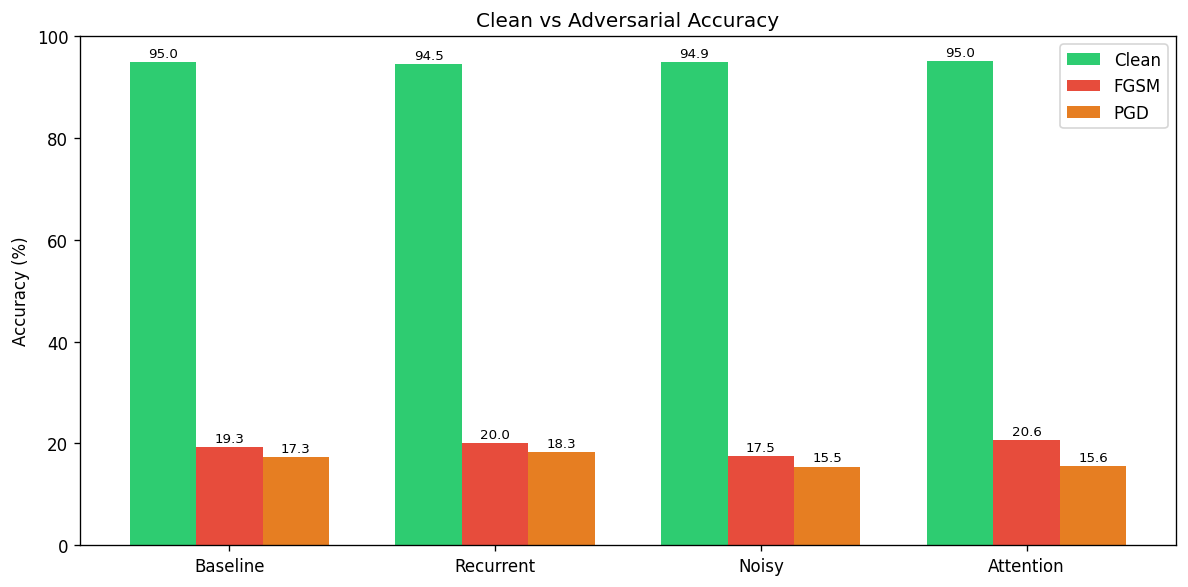

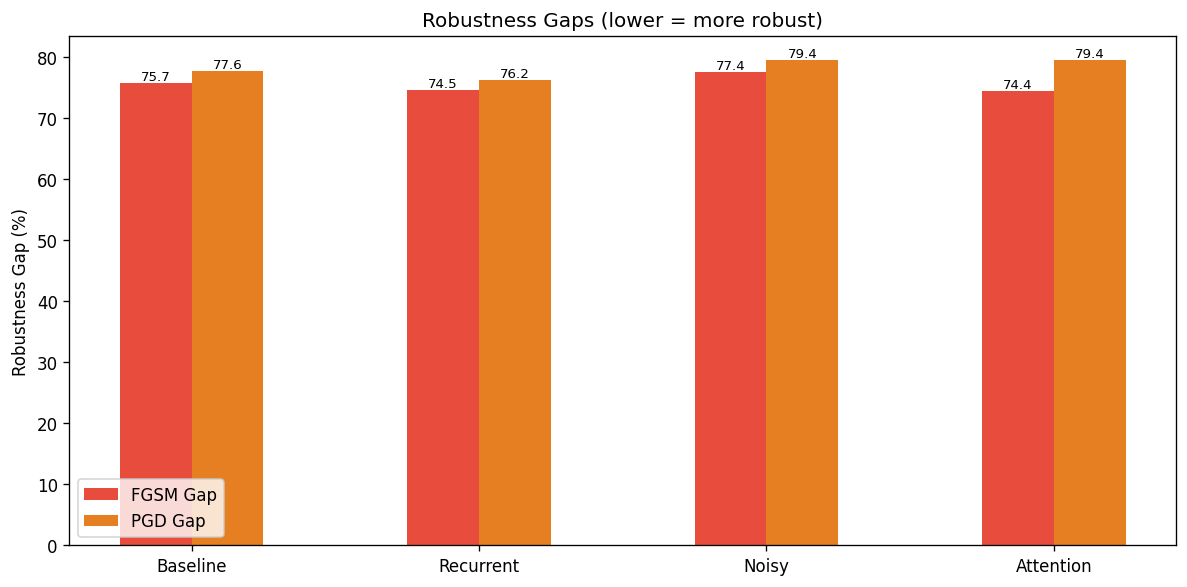

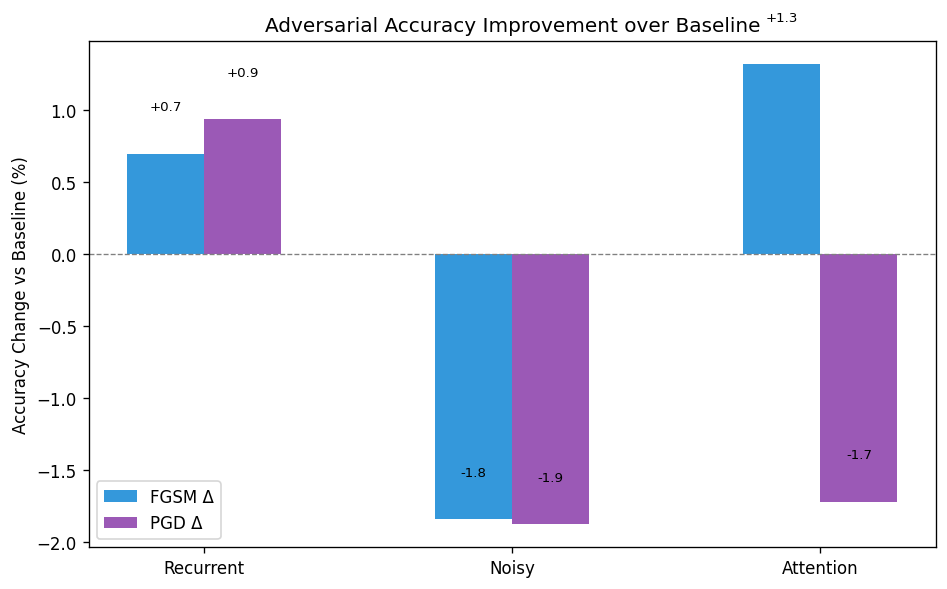

In [17]:
# ── Bar Charts ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

names = list(results.keys())
clean_accs = [results[n]["clean_acc"] for n in names]
fgsm_accs  = [results[n]["fgsm_acc"]  for n in names]
pgd_accs   = [results[n]["pgd_acc"]   for n in names]
fgsm_gaps  = [results[n]["fgsm_gap"]  for n in names]
pgd_gaps   = [results[n]["pgd_gap"]   for n in names]

x = np.arange(len(names))
w = 0.25

# Chart 1: Clean vs Adversarial Accuracy
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, clean_accs, w, label="Clean", color="#2ecc71")
ax.bar(x,     fgsm_accs,  w, label="FGSM",  color="#e74c3c")
ax.bar(x + w, pgd_accs,   w, label="PGD",   color="#e67e22")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Clean vs Adversarial Accuracy")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_ylim(0, 100)
for i in range(len(names)):
    ax.text(i - w, clean_accs[i] + 1, f"{clean_accs[i]:.1f}", ha="center", fontsize=8)
    ax.text(i,     fgsm_accs[i]  + 1, f"{fgsm_accs[i]:.1f}",  ha="center", fontsize=8)
    ax.text(i + w, pgd_accs[i]   + 1, f"{pgd_accs[i]:.1f}",   ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("chart_accuracy_comparison.png")
plt.show()

# Chart 2: Robustness Gaps
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, fgsm_gaps, w, label="FGSM Gap", color="#e74c3c")
ax.bar(x + w/2, pgd_gaps,  w, label="PGD Gap",  color="#e67e22")
ax.set_ylabel("Robustness Gap (%)")
ax.set_title("Robustness Gaps (lower = more robust)")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
for i in range(len(names)):
    ax.text(i - w/2, fgsm_gaps[i] + 0.5, f"{fgsm_gaps[i]:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, pgd_gaps[i]  + 0.5, f"{pgd_gaps[i]:.1f}",  ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("chart_robustness_gaps.png")
plt.show()

# Chart 3: Improvement over Baseline
bio_names = [n for n in names if n != "Baseline"]
fgsm_imp = [results[n]["fgsm_acc"] - bl["fgsm_acc"] for n in bio_names]
pgd_imp  = [results[n]["pgd_acc"]  - bl["pgd_acc"]  for n in bio_names]
x2 = np.arange(len(bio_names))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x2 - w/2, fgsm_imp, w, label="FGSM Δ", color="#3498db")
ax.bar(x2 + w/2, pgd_imp,  w, label="PGD Δ",  color="#9b59b6")
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Accuracy Change vs Baseline (%)")
ax.set_title("Adversarial Accuracy Improvement over Baseline")
ax.set_xticks(x2)
ax.set_xticklabels(bio_names)
ax.legend()
for i in range(len(bio_names)):
    ax.text(i - w/2, fgsm_imp[i] + 0.3, f"{fgsm_imp[i]:+.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, pgd_imp[i]  + 0.3, f"{pgd_imp[i]:+.1f}",  ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("chart_improvement.png")
plt.show()

In [18]:
# ── Time-Step Analysis (Recurrent Model) ─────────────────────────────
# Test the hypothesis: more processing time (higher T) = more robust

# Need ART classifier for recurrent model
rec_cpu = copy.deepcopy(recurrent_model).to("cpu")
rec_cpu.eval()

timestep_results = {}

for T in [1, 2, 3, 4]:
    print(f"\n--- T = {T} ---")

    # Wrap forward to fix time_steps for ART (which calls model(x) without kwargs)
    class RecurrentWrapper(nn.Module):
        def __init__(self, base_model, t):
            super().__init__()
            self.base = base_model
            self.t = t
        def forward(self, x):
            return self.base(x, time_steps=self.t)

    wrapped = RecurrentWrapper(rec_cpu, T)
    wrapped.eval()

    art_clf_t = PyTorchClassifier(
        model=wrapped,
        loss=nn.CrossEntropyLoss(),
        optimizer=optim.SGD(wrapped.parameters(), lr=0.1, momentum=0.9),
        input_shape=(3, 32, 32),
        nb_classes=10,
        clip_values=(0.0, 1.0),
        device_type="cpu"
    )

    fgsm_t = FastGradientMethod(estimator=art_clf_t, eps=8/255, eps_step=8/255, batch_size=128)
    pgd_t  = ProjectedGradientDescent(estimator=art_clf_t, eps=8/255, eps_step=2/255,
                                       max_iter=10, num_random_init=1,
                                       batch_size=128, verbose=False)

    # Use GPU model with fixed T for clean acc
    class RecurrentWrapperGPU(nn.Module):
        def __init__(self, base_model, t):
            super().__init__()
            self.base = base_model
            self.t = t
        def forward(self, x):
            return self.base(x, time_steps=self.t)

    wrapped_gpu = RecurrentWrapperGPU(recurrent_model, T)
    wrapped_gpu.eval()

    acc_c = clean_accuracy(wrapped_gpu, test_loader, device)
    acc_f = adversarial_accuracy(art_clf_t, test_loader, fgsm_t)
    acc_p = adversarial_accuracy(art_clf_t, test_loader, pgd_t, n_batches=5)

    print(f"  Clean: {acc_c:.2f}%  FGSM: {acc_f:.2f}%  PGD: {acc_p:.2f}%")
    timestep_results[T] = {"clean": acc_c, "fgsm": acc_f, "pgd": acc_p}

print("\nTime-step analysis complete.")


--- T = 1 ---
  Clean: 93.54%  FGSM: 19.35%  PGD: 22.66%

--- T = 2 ---
  Clean: 94.19%  FGSM: 19.66%  PGD: 20.78%

--- T = 3 ---
  Clean: 94.52%  FGSM: 20.00%  PGD: 19.06%

--- T = 4 ---
  Clean: 94.53%  FGSM: 20.55%  PGD: 16.88%

Time-step analysis complete.


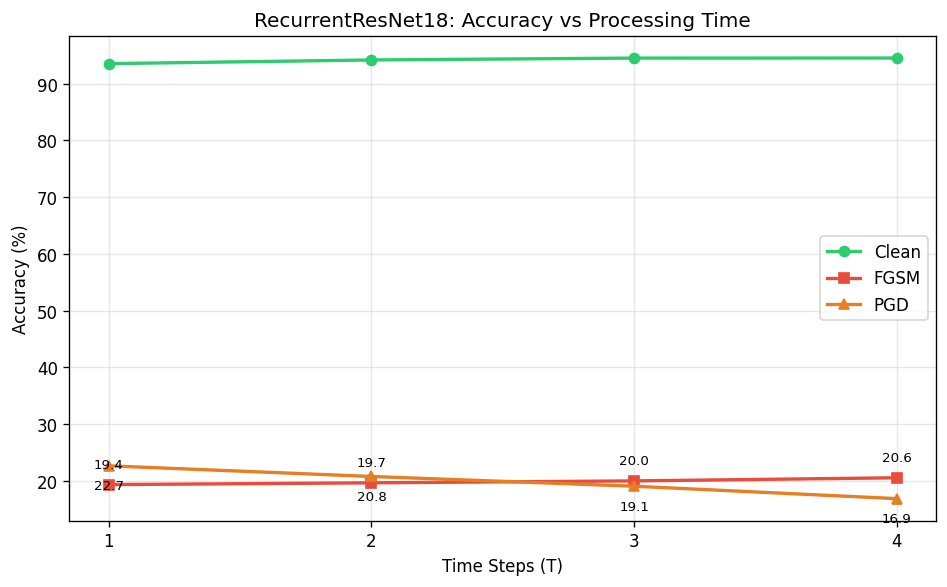


  Phases 2–4 Complete!


In [19]:
# ── Time-Step Chart ───────────────────────────────────────────────────
ts = sorted(timestep_results.keys())
clean_ts = [timestep_results[t]["clean"] for t in ts]
fgsm_ts  = [timestep_results[t]["fgsm"]  for t in ts]
pgd_ts   = [timestep_results[t]["pgd"]   for t in ts]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ts, clean_ts, "o-", label="Clean",  color="#2ecc71", linewidth=2)
ax.plot(ts, fgsm_ts,  "s-", label="FGSM",   color="#e74c3c", linewidth=2)
ax.plot(ts, pgd_ts,   "^-", label="PGD",    color="#e67e22", linewidth=2)
ax.set_xlabel("Time Steps (T)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("RecurrentResNet18: Accuracy vs Processing Time")
ax.set_xticks(ts)
ax.legend()
ax.grid(True, alpha=0.3)
for t_val in ts:
    ax.annotate(f"{timestep_results[t_val]['fgsm']:.1f}",
                (t_val, timestep_results[t_val]['fgsm']),
                textcoords="offset points", xytext=(0, 10), fontsize=8, ha="center")
    ax.annotate(f"{timestep_results[t_val]['pgd']:.1f}",
                (t_val, timestep_results[t_val]['pgd']),
                textcoords="offset points", xytext=(0, -14), fontsize=8, ha="center")
plt.tight_layout()
plt.savefig("chart_timestep_analysis.png")
plt.show()

print("\n" + "=" * 50)
print("  Phases 2–4 Complete!")
print("=" * 50)